# Analysis of Unbiasd MD simulations

## essential dynamics analysis

In [8]:
structure = parsePDB('../../step1_pdbreader.pdb')
dcd_free = parseDCD('md3_mol.dcd')

@> 5637 atoms and 1 coordinate set(s) were parsed in 0.09s.
@> DCD file contains 11110 coordinate sets for 5637 atoms.
@> DCD file was parsed in 8.59 seconds.
@> 717.56 MB parsed at input rate 83.55 MB/s.
@> 11110 coordinate sets parsed at input rate 1293 frame/s.


In [9]:
dcd_free.setCoords(structure)

In [10]:
dcd_free.setAtoms(structure.calpha)

In [11]:
dcd_free.superpose()

@> Superposition completed in 29.75 seconds.


In [12]:
eda_trajectory = EDA('MDM2 Trajectory')

In [13]:
eda_trajectory.buildCovariance( dcd_free, aligned=True )

@> Covariance is calculated using 11110 coordinate sets.


@> Covariance matrix calculated in 50.505257s.


In [14]:
eda_trajectory.calcModes('all')

@> 1074 modes were calculated in 0.52s.


## Project samples on the EDA space 

In [9]:
structure = parsePDB('../../step1_pdbreader.pdb')
dcd_free = parseDCD('md3_mol_aligned.dcd')

@> 5637 atoms and 1 coordinate set(s) were parsed in 0.06s.
@> DCD file contains 11111 coordinate sets for 5637 atoms.


@> DCD file was parsed in 11.32 seconds.
@> 717.62 MB parsed at input rate 63.38 MB/s.
@> 11111 coordinate sets parsed at input rate 981 frame/s.


In [10]:
dcd_free.setCoords(structure)

In [11]:
dcd_free.setAtoms(structure.calpha)

In [12]:
ref_struct = parsePDB(f'../../step1_pdbreader.pdb')

@> 5637 atoms and 1 coordinate set(s) were parsed in 0.16s.


In [13]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd_free])  

In [14]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [15]:
prj_new_ref = (1 / (dcd_free.numAtoms()*0.5) ) * np.dot(def_vec,gumk_eda.getArray() )

In [ ]:
# compute the projection of the eda vectors on the NM space
printOverlapTable(gumk_anm[:3], gumk_eda[:2]) 

## Quality of the EDA space 

### Cosine content 

In [4]:
u = mda.Universe('../../step1_pdbreader.pdb', 'md3_mol.dcd')
aligner = align.AlignTraj(u, u, select='backbone',in_memory=True).run()

/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [5]:
pc = pca.PCA(u, select='name CA',align=True, mean=None,n_components=3).run()

In [8]:
pch = pca.PCA(u, select='name CA',align=True, mean=None,n_components=3).run(start=0, stop=3000)

In [ ]:
backbone = u.select_atoms('name CA')
n_bb = len(backbone)
transformed = pc.transform(backbone, n_components=3)
transformed.shape

(11110, 3)

In [27]:
pc1 = pc.p_components[:, 0]
trans1 = transformed[:, 0]
projected = np.outer(trans1, pc1) + pc.mean.flatten()
coordinates = projected.reshape(len(trans1), -1, 3)

/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/analysis/pca.py:321: DeprecationWarning: The `p_components` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.p_components` instead.
  warnings.warn(wmsg, DeprecationWarning)


In [82]:
proj_prody_centered = np.array([transformed[:,i] - np.mean(transformed[:,i]) for i in range(3) ]).T

In [71]:
proj_prody_centered.shape

(11110, 3)

In [73]:
for i in range(3):
    cc = pca.cosine_content(proj_prody_centered, i)
    print(f"Cosine content for PC {i+1} = {cc:.3f}")

Cosine content for PC 1 = 0.431
Cosine content for PC 2 = 0.027
Cosine content for PC 3 = 0.011


/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/analysis/pca.py:754: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  return ((2.0 / T) * (scipy.integrate.simps(cos*pca_space[:, i])) ** 2 /


### Convergence check

In [ ]:
df = pd.read_csv('cosine_content_blocks_ns.csv')

In [7]:
def triple_exp(t, k1, t1, k2, t2, k3, t3):
    return k1 * np.exp(-t / t1) + k2 * np.exp(-t / t2) + k3 * np.exp(-t / t3) + 1


In [8]:
p0 = [1, 1, 1, 1, 1,5]
t = df['Block_ns']
y = 1/df['Norm_omega']

In [9]:
params, covariance = curve_fit(triple_exp, t, y, p0=p0)

/home/davidelu/mambaforge/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_9660/2002164349.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(triple_exp, t, y, p0=p0)


In [10]:
k1, t1, k2, t2, k3, t3 = params
print(f"k1={k1:.3f}, t1={t1:.3f}, k2={k2:.3f}, t2={t2:.3f}, k3={k3:.3f}, t3={t3:.3f}")


k1=-5.989, t1=0.380, k2=-5.989, t2=0.380, k3=0.745, t3=481.068


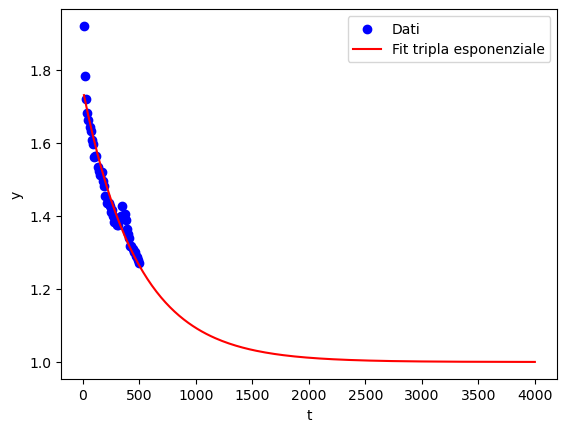

In [11]:
t_fit = np.linspace(np.min(t), 4000, 200)
y_fit = triple_exp(t_fit, *params)

plt.scatter(t, y, label='Dati', color='blue')
plt.plot(t_fit, y_fit, label='Fit tripla esponenziale', color='red')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.show()

## Phospholipid binding 

In [102]:
u = mda.Universe('ref_vis.pdb', 'md3_mol.xtc') # simulation with only the membrane centered
ref = mda.Universe('ref_vis.pdb')

In [103]:
lipids = u.select_atoms("not protein")

In [104]:
com = np.array([lipids.center_of_mass() for ts in u.trajectory])

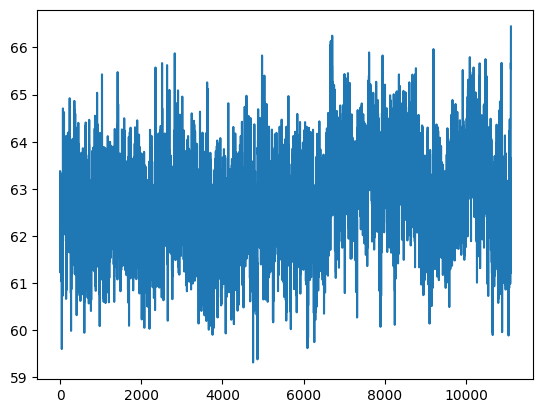

In [7]:
plt.plot(com[:,2])

In [105]:
upper_side = u.select_atoms("resid 374-385 398-427 458-505 and element P ")

In [106]:
com_us = np.array([upper_side.center_of_mass() for ts in u.trajectory])

In [107]:
thickness = com_us[:,2] - com[:,2] 

In [108]:
com_ds = np.round(com[:,2] - thickness, decimals=1)

In [96]:
a = u.select_atoms("id 7078")
a_poss = np.array([a.positions[0]  for ts in u.trajectory ])
z_dist = com_ds - a_poss[:,2] 

(-10.0, 13.5)

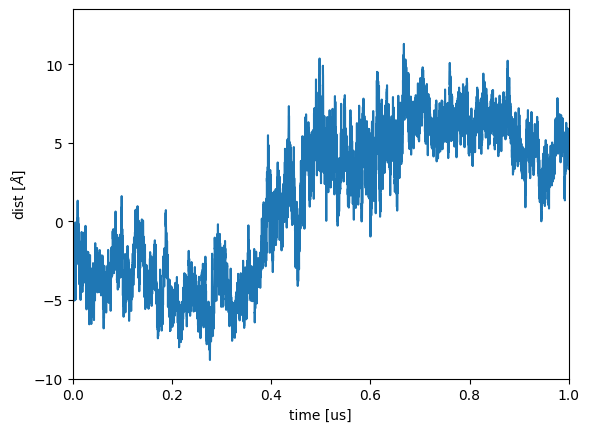

In [119]:
plt.plot(np.array(range(len(z_dist)))*1e-4,z_dist)
plt.xlabel("time [us]")
plt.ylabel(r"dist [$\AA$]")
plt.xlim(0.0,1.0)
plt.ylim(-10.,13.5)

Thi plot shows how the phospholipid phosphatidylglycerol first interacts with the protein at the acceptor domain and then it moves out of the memebrane because it interacts with the clef at the clamp. 

In [97]:
u = mda.Universe('ref_vis_lip.pdb', 'md3_cluster_lip.xtc')

In [98]:
a = u.select_atoms("id 7078")
a_poss = np.array([a.positions[0]  for ts in u.trajectory ])
binding = u.select_atoms("id 850 2497")
com_binding = np.array([binding.center_of_mass() for ts in u.trajectory])


In [86]:
binding_dist = [np.linalg.norm( com_binding[i] - a_poss[i]) for i in range(len(a_poss)) ]

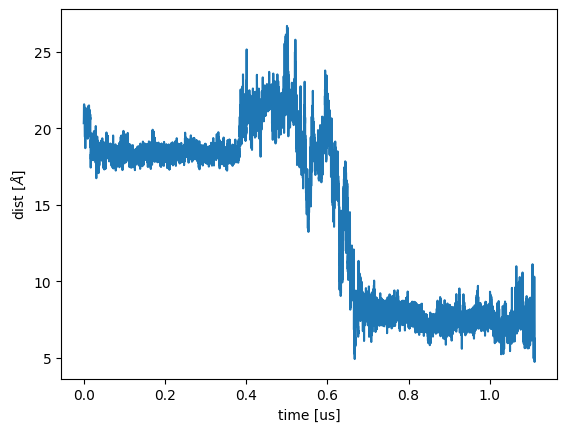

In [137]:
plt.plot(np.array(range(len(binding_dist)))*1e-4,binding_dist)
plt.xlabel("time [us]")
plt.ylabel(r"dist [$\AA$]")
#plt.xlim(0.0,1.0)
#plt.ylim(-10.,13.5)
plt.show()